# BERT Shortcut Analysis — Future Works Notebook

**Project:** BERT Shortcut Learning in Scientific Fact-Verification Tasks  
**Dataset:** PubHealth (`bigbio/pubhealth`)  

This notebook implements the **5 Future Work experiments** planned in the midterm report:

| # | Experiment | What it tests |
|---|-----------|---------------|
| FW1 | Synonym-Swap Contrastive Test | Does confidence drop when surface overlap is removed but meaning is preserved? |
| FW2 | Attention Masking Experiment | Does accuracy drop when high-overlap tokens are masked at inference? |
| FW3 | Probe Classifier | Are shortcut features linearly encoded in BERT's [CLS] embeddings? |
| FW4 | NEI Deep-Dive | Is NEI a genuine label or a garbage bin for edge cases? |
| FW5 | Error Analysis (Top-50) | What shortcut types drive the highest-confidence wrong predictions? |

**Prerequisites:** Run the baseline BERT training first (or provide a saved checkpoint).  
The notebook will fine-tune `bert-base-uncased` on PubHealth if no checkpoint exists.


## 0. Install & Imports

In [ ]:
# Install dependencies
!pip install -q torch transformers datasets scikit-learn matplotlib seaborn scipy spacy nltk
!python -m spacy download en_core_web_sm -q
!python -m nltk.downloader stopwords wordnet omw-1.4 -q
!pip install datasets==3.6.0

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 110.1 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.
<frozen runpy>:128: RuntimeWarning: 'nltk.downloader' found in sys.modules after import of package 'nltk', but prior to execution of 'nltk.downloader'; this may result in unpredictable behaviour
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 491.5/491.5 kB 13.7 MB/s eta 0:00:00
  Attempting uninstall: datasets
    Found existing installation: datasets 4.0.0
    Uninstalling datasets-4.0.0:
      Successfully uninstalled datasets-4.0.0


In [ ]:
import os, json, random, re, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from collections import Counter
from math import log

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
from torch.optim import AdamW
from datasets import load_dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    get_linear_schedule_with_warmup,
)
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, f1_score,
)
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler as SKScaler
from scipy.stats import pearsonr, spearmanr

import nltk
from nltk.stem import PorterStemmer
from nltk.corpus import stopwords, wordnet

try:
    import spacy
    nlp = spacy.load("en_core_web_sm")
    SPACY_AVAILABLE = True
    print("✓ spaCy loaded")
except Exception:
    warnings.warn("spaCy not found — NER features disabled.")
    SPACY_AVAILABLE = False

for pkg in ("stopwords", "wordnet", "omw-1.4"):
    try:
        nltk.data.find(f"corpora/{pkg}")
    except LookupError:
        nltk.download(pkg, quiet=True)

STOP_WORDS = set(stopwords.words("english"))
STEMMER    = PorterStemmer()
print("✓ All imports successful")

✓ spaCy loaded
✓ All imports successful


## 1. Config & Reproducibility

In [ ]:
SEED        = 42
MAX_LEN     = 128
BATCH_SIZE  = 16
EPOCHS      = 8
PATIENCE    = 2
LR          = 2e-5
MODEL_NAME  = "bert-base-uncased"
LABEL_NAMES = ["supports", "refutes", "not_enough_info"]
OUTPUT_DIR  = "./future_works_outputs"
CHECKPOINT_DIR = "./bert_baseline_checkpoint"
os.makedirs(OUTPUT_DIR, exist_ok=True)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

Device: cuda


## 2. Data Loading & Helper Functions

In [ ]:
def load_pubhealth():
    """Load PubHealth into (claim, evidence, label) format."""
    print("Loading PubHealth...")

    dataset = load_dataset("bigbio/pubhealth", "pubhealth_bigbio_pairs")


    def convert_split(split):
        df = split.to_pandas().copy()

        # Map fields
        df["claim"] = df["text_1"].astype(str).str.strip()
        df["evidence"] = df["text_2"].astype(str).str.strip()

        # Normalize labels
        def normalize(label):
            label = str(label).strip().lower()
            if label == "true":
                return 0   # supports
            elif label == "false":
                return 1   # refutes
            elif label in {"mixture", "unproven"}:
                return 2   # NEI / neutral
            return None

        df["label"] = df["label"].apply(normalize)

        # Clean
        df = df.dropna(subset=["claim", "evidence", "label"]).copy()
        df["label"] = df["label"].astype(int)

        return df[["claim", "evidence", "label"]]

    train_df = convert_split(dataset["train"])
    dev_df   = convert_split(dataset["validation"])
    test_df  = convert_split(dataset["test"])

    print(f"Train: {len(train_df)} | Dev: {len(dev_df)} | Test: {len(test_df)}")
    print("Train label distribution:", dict(Counter(train_df["label"])))

    return train_df, dev_df, test_df

## 3. PyTorch Dataset & Model Utilities

In [ ]:
class PubHealthDataset(Dataset):
    def __init__(self, df, tokenizer, max_len=MAX_LEN):
        self.df, self.tok, self.max_len = df, tokenizer, max_len

    def __len__(self): return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        enc = self.tok(
            str(row.claim), str(row.evidence),
            max_length=self.max_len, padding="max_length",
            truncation=True, return_tensors="pt"
        )
        return {
            "input_ids":      enc["input_ids"].squeeze(),
            "attention_mask": enc["attention_mask"].squeeze(),
            "token_type_ids": enc.get("token_type_ids",
                              torch.zeros(self.max_len, dtype=torch.long)).squeeze(),
            "label":    torch.tensor(int(row.label), dtype=torch.long),
            "claim":    str(row.claim),
            "evidence": str(row.evidence),
        }


def train_epoch(model, loader, optimizer, scheduler, criterion):
    model.train()
    total_loss = correct = total = 0
    for batch in loader:
        ids, mask, tt, labs = (
            batch["input_ids"].to(DEVICE),
            batch["attention_mask"].to(DEVICE),
            batch["token_type_ids"].to(DEVICE),
            batch["label"].to(DEVICE)
        )
        optimizer.zero_grad()
        logits = model(input_ids=ids, attention_mask=mask, token_type_ids=tt).logits
        loss   = criterion(logits, labs)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step(); scheduler.step()
        total_loss += loss.item()
        correct    += (logits.argmax(-1) == labs).sum().item()
        total      += labs.size(0)
    return total_loss / len(loader), correct / total


@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    total_loss = correct = total = 0
    all_preds, all_labels, all_probs = [], [], []
    for batch in loader:
        ids, mask, tt, labs = (
            batch["input_ids"].to(DEVICE),
            batch["attention_mask"].to(DEVICE),
            batch["token_type_ids"].to(DEVICE),
            batch["label"].to(DEVICE)
        )
        logits = model(input_ids=ids, attention_mask=mask, token_type_ids=tt).logits
        probs  = torch.softmax(logits, -1)
        loss   = criterion(logits, labs)
        total_loss += loss.item()
        preds       = logits.argmax(-1)
        correct    += (preds == labs).sum().item()
        total      += labs.size(0)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labs.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())
    return total_loss/len(loader), correct/total, np.array(all_preds), np.array(all_labels), np.array(all_probs)


def train_baseline(train_ds, val_ds):
    """Fine-tune baseline BERT with early stopping. Saves/loads checkpoint."""
    if os.path.exists(CHECKPOINT_DIR):
        print(f"Loading existing checkpoint from {CHECKPOINT_DIR}...")
        model = AutoModelForSequenceClassification.from_pretrained(
            CHECKPOINT_DIR, num_labels=3, ignore_mismatched_sizes=True
        ).to(DEVICE)
        return model

    print("Training baseline BERT (no checkpoint found)...")
    model = AutoModelForSequenceClassification.from_pretrained(
        MODEL_NAME, num_labels=3, ignore_mismatched_sizes=True
    ).to(DEVICE)
    train_loader = DataLoader(train_ds, BATCH_SIZE, shuffle=True,  num_workers=0)
    val_loader   = DataLoader(val_ds,   BATCH_SIZE, shuffle=False, num_workers=0)
    criterion    = nn.CrossEntropyLoss()
    optimizer    = AdamW(model.parameters(), lr=LR, weight_decay=0.01)
    total_steps  = len(train_loader) * EPOCHS
    scheduler    = get_linear_schedule_with_warmup(
        optimizer, int(0.1*total_steps), total_steps)

    best_loss, pat_count, best_state = float("inf"), 0, None
    for epoch in range(1, EPOCHS+1):
        tr_loss, tr_acc = train_epoch(model, train_loader, optimizer, scheduler, criterion)
        vl_loss, vl_acc, _, _, _ = evaluate(model, val_loader, criterion)
        print(f"  Epoch {epoch}/{EPOCHS} | Train {tr_loss:.4f}/{tr_acc:.4f} | Val {vl_loss:.4f}/{vl_acc:.4f}")
        if vl_loss < best_loss - 1e-4:
            best_loss  = vl_loss
            pat_count  = 0
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            print("    ↓ Checkpoint saved")
        else:
            pat_count += 1
            if pat_count >= PATIENCE:
                print(f"  Early stopping at epoch {epoch}")
                break

    model.load_state_dict({k: v.to(DEVICE) for k, v in best_state.items()})
    model.save_pretrained(CHECKPOINT_DIR)
    print(f"  Saved → {CHECKPOINT_DIR}")
    return model

print("✓ Dataset & model utilities defined")

✓ Dataset & model utilities defined


## 4. Data Preparation & Model Training

In [ ]:
from collections import Counter
from math import log
import re

# You may already have these, but define if missing
STOP_WORDS = set([
    "the","a","an","and","or","is","are","was","were","be","been","being",
    "in","on","at","to","of","for","with","about","against","between",
    "into","through","during","before","after","above","below",
    "from","up","down","out","off","over","under","again","further",
    "then","once","here","there","when","where","why","how"
])

# Simple stemmer fallback (if you don't want nltk dependency)
class SimpleStemmer:
    def stem(self, word):
        return word  # no stemming (safe fallback)

STEMMER = SimpleStemmer()

# -----------------------------
# TF-IDF FUNCTIONS
# -----------------------------
def _stem_filter(text):
    tokens = re.findall(r"\b\w+\b", text.lower())
    return [STEMMER.stem(t) for t in tokens if t not in STOP_WORDS]

def _tfidf_weights(corpus_tokens):
    N = len(corpus_tokens)
    df = Counter()

    for tokens in corpus_tokens:
        df.update(set(tokens))

    return {t: log((N + 1) / (c + 1)) + 1.0 for t, c in df.items()}

def build_idf(df):
    corpus = [
        _stem_filter(row["claim"] + " " + row["evidence"])
        for _, row in df.iterrows()
    ]
    return _tfidf_weights(corpus)

def tfidf_overlap(claim, evidence, idf):
    c = set(_stem_filter(claim))
    e = _stem_filter(evidence)

    if not e:
        return 0.0

    denom = sum(idf.get(w, 1.0) for w in e)
    numer = sum(idf.get(w, 1.0) for w in e if w in c)

    return numer / denom if denom > 0 else 0.0
def has_negation(text):
    text = str(text).lower()

    # handle contractions like "don't", "isn't"
    if re.search(r"\b\w+n't\b", text):
        return 1

    neg_words = {
        "not", "no", "never", "neither", "nor",
        "nobody", "nothing", "none", "without",
        "lack", "lacking", "absent",
        "fail", "fails", "failed",
        "false", "incorrect", "untrue",
        "deny", "denies", "denied"
    }

    tokens = set(re.findall(r"\b\w+\b", text))
    return int(bool(tokens & neg_words))
def compute_features(df, idf):
    out = df.copy()
    out["overlap"] = out.apply(
        lambda r: tfidf_overlap(r["claim"], r["evidence"], idf),
        axis=1
    )
    out["negation"] = out["evidence"].apply(has_negation)
    out["claim_len"] = out["claim"].apply(lambda x: len(str(x).split()))
    out["evid_len"] = out["evidence"].apply(lambda x: len(str(x).split()))
    out["len_ratio"] = out["claim_len"] / out["evid_len"].replace(0, np.nan)
    out["label_name"] = out["label"].map({0: "supports", 1: "refutes", 2: "neutral"})
    return out

In [ ]:
# Load data
train_df, dev_df, test_df = load_pubhealth()

# Build IDF from training split only
print("Building TF-IDF weights...")
idf = build_idf(train_df)

# Tokenizer & datasets
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
train_ds = PubHealthDataset(train_df, tokenizer)
val_ds = PubHealthDataset(dev_df, tokenizer)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

# Train or load baseline
model = train_baseline(train_ds, val_ds)

# Get baseline predictions on val set
criterion = nn.CrossEntropyLoss()
_, _, base_preds, base_labels, base_probs = evaluate(model, val_loader, criterion)

# Compute shortcut features on val
val_feat = compute_features(dev_df, idf)

print(f"\nBaseline Val Accuracy: {accuracy_score(base_labels, base_preds):.4f}")
print(classification_report(base_labels, base_preds, target_names=LABEL_NAMES))

Loading PubHealth...
Train: 9804 | Dev: 1223 | Test: 1231
Train label distribution: {1: 3001, 2: 1725, 0: 5078}
Building TF-IDF weights...
Loading existing checkpoint from ./bert_baseline_checkpoint...


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]


Baseline Val Accuracy: 0.7228
                 precision    recall  f1-score   support

       supports       0.86      0.85      0.85       635
        refutes       0.64      0.73      0.68       382
not_enough_info       0.42      0.33      0.37       206

       accuracy                           0.72      1223
      macro avg       0.64      0.63      0.63      1223
   weighted avg       0.72      0.72      0.72      1223



---
## FW1: Synonym-Swap Contrastive Test

**Hypothesis:** If BERT relies on lexical overlap as a shortcut, swapping overlapping tokens with synonyms (meaning-preserving) should cause a measurable drop in confidence — even though the semantic content is unchanged.

**Method:**
1. Select the ~100 high-overlap val examples
2. Replace overlapping claim↔evidence tokens with WordNet synonyms
3. Measure original vs. swapped confidence and prediction stability

In [ ]:
def get_synonym(word):
    """Return a WordNet synonym different from the input word, or None."""
    for syn in wordnet.synsets(word):
        for lemma in syn.lemmas():
            cand = lemma.name().replace("_", " ")
            if cand.lower() != word.lower() and " " not in cand:  # single-word only
                return cand
    return None


def synonym_swap_test(model, tokenizer, dev_df, idf, n_samples=100):
    """
    FW1: Synonym-Swap Contrastive Test.
    Swaps overlapping claim-evidence tokens with WordNet synonyms and
    measures whether BERT confidence drops despite preserved meaning.
    """
    print("=" * 60)
    print("FW1: SYNONYM-SWAP CONTRASTIVE TEST")
    print("=" * 60)

    feat_df  = compute_features(dev_df, idf)
    high_ov  = feat_df.nlargest(n_samples, "overlap").reset_index(drop=True)

    model.eval()
    results = []

    for _, row in high_ov.iterrows():
        claim    = str(row.claim)
        evidence = str(row.evidence)
        label    = int(row.label)

        c_words  = set(re.findall(r"\b\w+\b", claim.lower())) - STOP_WORDS
        e_tokens = re.findall(r"\b\w+\b", evidence)

        swap_map = {}
        for tok in e_tokens:
            if tok.lower() in c_words:
                syn = get_synonym(tok.lower())
                if syn:
                    swap_map[tok] = syn

        if not swap_map:
            continue

        swapped_ev = evidence
        for orig, syn in swap_map.items():
            swapped_ev = re.sub(r'\b' + re.escape(orig) + r'\b', syn,
                                swapped_ev, flags=re.IGNORECASE)

        def get_conf(c_text, e_text):
            enc = tokenizer(c_text, e_text, max_length=MAX_LEN,
                            padding="max_length", truncation=True, return_tensors="pt")
            with torch.no_grad():
                logits = model(
                    input_ids=enc["input_ids"].to(DEVICE),
                    attention_mask=enc["attention_mask"].to(DEVICE),
                    token_type_ids=enc.get("token_type_ids",
                        torch.zeros(MAX_LEN, dtype=torch.long).unsqueeze(0)).to(DEVICE),
                ).logits
            probs = torch.softmax(logits, -1).cpu().numpy()[0]
            return float(probs.max()), int(probs.argmax())

        orig_conf, orig_pred = get_conf(claim, evidence)
        swap_conf, swap_pred = get_conf(claim, swapped_ev)

        results.append({
            "label":            label,
            "label_name":       LABEL_NAMES[label],
            "orig_confidence":  orig_conf,
            "swap_confidence":  swap_conf,
            "conf_drop":        orig_conf - swap_conf,
            "orig_pred":        orig_pred,
            "swap_pred":        swap_pred,
            "pred_changed":     int(orig_pred != swap_pred),
            "n_tokens_swapped": len(swap_map),
            "overlap":          float(row.overlap),
            "orig_evidence":    evidence,
            "swap_evidence":    swapped_ev,
            "claim":            claim,
        })

    if not results:
        print("No synonym swaps found. Check WordNet installation.")
        return pd.DataFrame()

    res = pd.DataFrame(results)

    # ── Summary statistics ─────────────────────────────────────────────────────
    print(f"\n  Samples with valid swaps:  {len(res)} / {n_samples}")
    print(f"  Mean confidence — original:  {res['orig_confidence'].mean():.4f}")
    print(f"  Mean confidence — swapped:   {res['swap_confidence'].mean():.4f}")
    print(f"  Mean confidence drop (Δ):    {res['conf_drop'].mean():.4f}")
    print(f"  Predictions changed:         {res['pred_changed'].mean()*100:.1f}%")
    print(f"  Mean tokens swapped:         {res['n_tokens_swapped'].mean():.1f}")

    t_stat, p_val = __import__('scipy.stats', fromlist=['ttest_rel']).ttest_rel(
        res['orig_confidence'], res['swap_confidence'])
    print(f"  Paired t-test: t={t_stat:.3f}, p={p_val:.4e}")

    if res['conf_drop'].mean() > 0.02:
        print("  ⚠  Significant confidence drop → BERT exploits surface overlap!")
    else:
        print("  ✓  Confidence stable → BERT may use semantic matching, not just surface.")

    print("\n  Confidence drop by label:")
    print(res.groupby("label_name")[["conf_drop","pred_changed"]].mean().round(4).to_string())

    # ── 5 example pairs ────────────────────────────────────────────────────────
    print("\n  Sample swapped pairs (top 5 by conf_drop):")
    top5 = res.nlargest(5, "conf_drop")
    for i, r in top5.iterrows():
        print(f"\n  [{r.label_name}] Conf: {r.orig_confidence:.3f} → {r.swap_confidence:.3f}  (Δ={r.conf_drop:.3f})")
        print(f"    Orig: {r.orig_evidence[:80]}...")
        print(f"    Swap: {r.swap_evidence[:80]}...")

    # Save CSV
    save_path = os.path.join(OUTPUT_DIR, "fw1_synonym_swap.csv")
    res.to_csv(save_path, index=False)
    print(f"\n  Saved → {save_path}")
    return res


swap_df = synonym_swap_test(model, tokenizer, dev_df, idf, n_samples=150)

FW1: SYNONYM-SWAP CONTRASTIVE TEST

  Samples with valid swaps:  149 / 150
  Mean confidence — original:  0.6873
  Mean confidence — swapped:   0.6663
  Mean confidence drop (Δ):    0.0210
  Predictions changed:         9.4%
  Mean tokens swapped:         5.8
  Paired t-test: t=2.357, p=1.9754e-02
  ⚠  Significant confidence drop → BERT exploits surface overlap!

  Confidence drop by label:
                 conf_drop  pred_changed
label_name                              
not_enough_info     0.0211        0.0833
refutes             0.0416        0.0952
supports           -0.0050        0.1000

  Sample swapped pairs (top 5 by conf_drop):

  [refutes] Conf: 0.797 → 0.461  (Δ=0.337)
    Orig: Reports of a secret tape recorded aboard the doomed space shuttle Challenger tha...
    Swap: Reports of a arcanum taping record alongside the lost infinite shuttlecock rival...

  [refutes] Conf: 0.801 → 0.550  (Δ=0.251)
    Orig: Radnofsky says the attorney general requires rape victims pay for rap

---
## FW2: Attention Masking Experiment

**Hypothesis:** If BERT uses high-overlap tokens as shortcuts, masking them at inference time should cause accuracy and confidence to drop.

**Method:**
1. For each example, identify top-k tokens shared between claim and evidence
2. Set their attention mask to 0 (force BERT to ignore them)
3. Compare accuracy/confidence before and after masking

In [ ]:
def attention_masking_experiment(model, tokenizer, dev_df, idf, n_samples=300, mask_top_k=3):
    """
    FW2: Attention Masking Experiment.
    Masks the top-k highest-IDF overlap tokens at inference and measures
    accuracy & confidence drop.
    """
    print("=" * 60)
    print(f"FW2: ATTENTION MASKING EXPERIMENT  (mask_top_k={mask_top_k})")
    print("=" * 60)

    feat_df   = compute_features(dev_df, idf)
    sample_df = feat_df.sample(min(n_samples, len(feat_df)),
                               random_state=SEED).reset_index(drop=True)

    model.eval()
    results = []

    for _, row in sample_df.iterrows():
        claim    = str(row.claim)
        evidence = str(row.evidence)
        label    = int(row.label)

        enc = tokenizer(claim, evidence, max_length=MAX_LEN,
                        padding="max_length", truncation=True, return_tensors="pt")
        input_ids      = enc["input_ids"].clone()
        attention_mask = enc["attention_mask"].clone()
        token_type_ids = enc.get(
            "token_type_ids",
            torch.zeros(MAX_LEN, dtype=torch.long).unsqueeze(0)).clone()

        # Find overlapping token positions
        tokens        = tokenizer.convert_ids_to_tokens(input_ids[0].tolist())
        c_stems       = set(_stem_filter(claim))
        e_stem_set    = set(_stem_filter(evidence))
        overlap_stems = c_stems & e_stem_set

        # Score each token by IDF weight of its stem
        scored = []
        for pos, tok in enumerate(tokens):
            if tok in ("[CLS]", "[SEP]", "[PAD]"): continue
            stem = STEMMER.stem(re.sub(r"^##", "", tok).lower())
            if stem in overlap_stems:
                scored.append((idf.get(stem, 1.0), pos))
        # Mask top-k by IDF weight (highest-information overlaps first)
        scored.sort(reverse=True)
        mask_positions = [p for _, p in scored[:mask_top_k]]

        def run(attn):
            with torch.no_grad():
                logits = model(
                    input_ids=input_ids.to(DEVICE),
                    attention_mask=attn.to(DEVICE),
                    token_type_ids=token_type_ids.to(DEVICE),
                ).logits
            p = torch.softmax(logits, -1).cpu().numpy()[0]
            return float(p.max()), int(p.argmax())

        orig_conf, orig_pred = run(attention_mask)
        masked_attn = attention_mask.clone()
        for pos in mask_positions:
            masked_attn[0, pos] = 0
        mask_conf, mask_pred = run(masked_attn)

        results.append({
            "label":           label,
            "label_name":      LABEL_NAMES[label],
            "orig_pred":       orig_pred,
            "mask_pred":       mask_pred,
            "orig_correct":    int(orig_pred == label),
            "mask_correct":    int(mask_pred == label),
            "orig_confidence": orig_conf,
            "mask_confidence": mask_conf,
            "conf_drop":       orig_conf - mask_conf,
            "pred_changed":    int(orig_pred != mask_pred),
            "n_masked":        len(mask_positions),
            "overlap":         float(row.overlap),
        })

    res = pd.DataFrame(results)

    # ── Summary ─────────────────────────────────────────────────────────────────
    orig_acc  = res["orig_correct"].mean()
    mask_acc  = res["mask_correct"].mean()
    delta_acc = mask_acc - orig_acc

    print(f"\n  Samples tested:           {len(res)}")
    print(f"  Original accuracy:        {orig_acc:.4f}")
    print(f"  Masked accuracy:          {mask_acc:.4f}  (Δ = {delta_acc:+.4f})")
    print(f"  Mean confidence drop:     {res['conf_drop'].mean():.4f}")
    print(f"  Predictions changed:      {res['pred_changed'].mean()*100:.1f}%")

    if orig_acc - mask_acc > 0.03:
        print("  ⚠  Accuracy drops after masking → overlap tokens are load-bearing (SHORTCUT!)")
    else:
        print("  ✓  Accuracy stable → BERT uses broader contextual signals.")

    print("\n  Per-label breakdown:")
    agg = res.groupby("label_name")[["orig_correct","mask_correct","conf_drop"]].mean()
    agg["acc_drop"] = agg["orig_correct"] - agg["mask_correct"]
    print(agg.round(4).to_string())

    save_path = os.path.join(OUTPUT_DIR, "fw2_attention_masking.csv")
    res.to_csv(save_path, index=False)
    print(f"\n  Saved → {save_path}")
    return res


mask_df = attention_masking_experiment(model, tokenizer, dev_df, idf, n_samples=400, mask_top_k=3)

FW2: ATTENTION MASKING EXPERIMENT  (mask_top_k=3)

  Samples tested:           400
  Original accuracy:        0.7250
  Masked accuracy:          0.7250  (Δ = +0.0000)
  Mean confidence drop:     0.0043
  Predictions changed:      1.2%
  ✓  Accuracy stable → BERT uses broader contextual signals.

  Per-label breakdown:
                 orig_correct  mask_correct  conf_drop  acc_drop
label_name                                                      
not_enough_info        0.2754        0.2754     0.0040    0.0000
refutes                0.7787        0.7869     0.0082   -0.0082
supports               0.8421        0.8373     0.0022    0.0048

  Saved → ./future_works_outputs/fw2_attention_masking.csv


---
## FW3: Probe Classifier

**Hypothesis:** If BERT has learned to rely on shortcut features, those features should be **linearly decodable** from its [CLS] embeddings.

**Three probes:**
- **(A)** Shortcut-feature-only logistic regression → how predictive are surface features alone?
- **(B)** Linear probe on [CLS] embeddings → predict binarised high/low lexical overlap
- **(C)** Linear probe on [CLS] embeddings → predict gold label (sanity check)

In [ ]:
@torch.no_grad()
def extract_cls_embeddings(model, loader):
    """Extract [CLS] token from the last hidden state."""
    model.eval()
    embeddings, labels = [], []
    for batch in loader:
        ids  = batch["input_ids"].to(DEVICE)
        mask = batch["attention_mask"].to(DEVICE)
        tt   = batch["token_type_ids"].to(DEVICE)
        labs = batch["label"]
        out  = model(input_ids=ids, attention_mask=mask, token_type_ids=tt,
                     output_hidden_states=True)
        cls_emb = out.hidden_states[-1][:, 0, :].cpu().numpy()
        embeddings.append(cls_emb)
        labels.extend(labs.numpy())
    return np.vstack(embeddings), np.array(labels)


def probe_classifier_experiment(model, tokenizer, train_df, dev_df, idf):
    """
    FW3: Probe Classifier.
    Tests whether shortcut features are linearly encoded in BERT [CLS] embeddings.
    """
    print("=" * 60)
    print("FW3: PROBE CLASSIFIER")
    print("=" * 60)

    train_feat = compute_features(train_df, idf)
    val_feat   = compute_features(dev_df,   idf)

    # ── (A) Shortcut features only ─────────────────────────────────────────────
    feat_cols = ["overlap", "negation", "len_ratio"]
    X_tr = train_feat[feat_cols].fillna(0).values
    y_tr = train_feat["label"].values
    X_va = val_feat[feat_cols].fillna(0).values
    y_va = val_feat["label"].values

    sc = SKScaler()
    lr_feat = LogisticRegression(max_iter=500, random_state=SEED, class_weight="balanced")
    lr_feat.fit(sc.fit_transform(X_tr), y_tr)
    feat_preds = lr_feat.predict(sc.transform(X_va))
    feat_acc   = accuracy_score(y_va, feat_preds)
    feat_f1    = f1_score(y_va, feat_preds, average="macro")

    print(f"\n  (A) Shortcut-feature-only logistic regression:")
    print(f"      Accuracy = {feat_acc:.4f}  |  Macro-F1 = {feat_f1:.4f}")
    print(f"      (This is the surface-cue baseline — no BERT at all)")
    print(classification_report(y_va, feat_preds, target_names=LABEL_NAMES))

    # ── (B) Probe: predict high/low overlap from [CLS] ─────────────────────────
    print("  Extracting [CLS] embeddings from val set...")
    cls_embs, gold_labels = extract_cls_embeddings(model, val_loader)

    overlap_vals   = val_feat["overlap"].fillna(0).values
    median_ov      = np.median(overlap_vals)
    binary_overlap = (overlap_vals >= median_ov).astype(int)
    chance_acc     = max(np.mean(binary_overlap), 1 - np.mean(binary_overlap))

    X_pr_tr, X_pr_te, y_pr_tr, y_pr_te = train_test_split(
        cls_embs, binary_overlap, test_size=0.5, random_state=SEED)
    sc2 = SKScaler()
    lr_ov = LogisticRegression(max_iter=200, random_state=SEED)
    lr_ov.fit(sc2.fit_transform(X_pr_tr), y_pr_tr)
    probe_preds = lr_ov.predict(sc2.transform(X_pr_te))
    probe_acc   = accuracy_score(y_pr_te, probe_preds)

    print(f"\n  (B) Linear probe — predict high/low overlap from [CLS]:")
    print(f"      Probe accuracy = {probe_acc:.4f}  (chance = {chance_acc:.4f})")
    if probe_acc > chance_acc + 0.05:
        print("      ⚠  Overlap is linearly encoded in BERT's representation!")
    else:
        print("      ✓  Overlap not strongly linearly decodable from [CLS].")

    # ── (C) Probe: predict gold label (sanity check) ────────────────────────────
    X_gl_tr, X_gl_te, y_gl_tr, y_gl_te = train_test_split(
        cls_embs, gold_labels, test_size=0.5, stratify=gold_labels, random_state=SEED)
    sc3 = SKScaler()
    lr_label = LogisticRegression(max_iter=500, random_state=SEED, class_weight="balanced")
    lr_label.fit(sc3.fit_transform(X_gl_tr), y_gl_tr)
    label_preds = lr_label.predict(sc3.transform(X_gl_te))
    label_acc   = accuracy_score(y_gl_te, label_preds)
    label_f1    = f1_score(y_gl_te, label_preds, average="macro")

    print(f"\n  (C) Linear probe — predict gold label from [CLS] (sanity):")
    print(f"      Accuracy = {label_acc:.4f}  |  Macro-F1 = {label_f1:.4f}")
    print(f"      (High = BERT embeddings capture task-relevant signal)")

    probe_results = {
        "feature_only_accuracy":  feat_acc,
        "feature_only_macro_f1":  feat_f1,
        "overlap_probe_accuracy": probe_acc,
        "overlap_probe_chance":   chance_acc,
        "label_probe_accuracy":   label_acc,
        "label_probe_macro_f1":   label_f1,
    }
    save_path = os.path.join(OUTPUT_DIR, "fw3_probe_results.json")
    with open(save_path, "w") as f:
        json.dump(probe_results, f, indent=2)
    print(f"\n  Saved → {save_path}")
    return probe_results, cls_embs, gold_labels, feat_preds, y_va


probe_results, cls_embs, gold_labels, feat_preds, y_va = probe_classifier_experiment(
    model, tokenizer, train_df, dev_df, idf)

FW3: PROBE CLASSIFIER

  (A) Shortcut-feature-only logistic regression:
      Accuracy = 0.5143  |  Macro-F1 = 0.4069
      (This is the surface-cue baseline — no BERT at all)
                 precision    recall  f1-score   support

       supports       0.73      0.73      0.73       635
        refutes       0.44      0.06      0.11       382
not_enough_info       0.26      0.68      0.38       206

       accuracy                           0.51      1223
      macro avg       0.48      0.49      0.41      1223
   weighted avg       0.56      0.51      0.48      1223

  Extracting [CLS] embeddings from val set...

  (B) Linear probe — predict high/low overlap from [CLS]:
      Probe accuracy = 0.7843  (chance = 0.5004)
      ⚠  Overlap is linearly encoded in BERT's representation!

  (C) Linear probe — predict gold label from [CLS] (sanity):
      Accuracy = 0.6601  |  Macro-F1 = 0.5725
      (High = BERT embeddings capture task-relevant signal)

  Saved → ./future_works_outputs/fw3

---
## FW4: NEI Deep-Dive

**Question:** Is the `not_enough_info` (NEI) label a genuine, well-defined category, or is it a catch-all for ambiguous/borderline cases?

**Analysis:**
- Feature distribution: does NEI look systematically different from SUPPORTS/REFUTES?
- Model confidence on NEI vs. other classes
- Where does BERT misclassify NEI?
- Evidence length and lexical overlap for NEI

In [ ]:
def nei_deep_dive(dev_df, base_preds, base_probs, idf):
    """
    FW4: NEI Deep-Dive.
    Investigates whether NEI is a genuine label or an annotation artefact.
    """
    print("=" * 60)
    print("FW4: NEI DEEP-DIVE")
    print("=" * 60)

    feat_df = compute_features(dev_df, idf)
    feat_df["pred"]       = base_preds
    feat_df["pred_name"]  = feat_df["pred"].map({i: n for i, n in enumerate(LABEL_NAMES)})
    feat_df["correct"]    = (feat_df["pred"] == feat_df["label"]).astype(int)
    feat_df["confidence"] = base_probs.max(axis=1)
    feat_df["nei_prob"]   = base_probs[:, 2]  # P(NEI)

    nei_df  = feat_df[feat_df["label_name"] == "not_enough_info"]
    pos_df  = feat_df[feat_df["label_name"] != "not_enough_info"]

    print(f"\n  NEI samples: {len(nei_df)}  |  Non-NEI samples: {len(pos_df)}")

    # ── 1. Feature distributions ─────────────────────────────────────────────
    print("\n  ── Shortcut feature comparison ──")
    print(f"  {'Feature':<18} {'NEI':>10} {'non-NEI':>10} {'Δ':>8}")
    print("  " + "-" * 52)
    for col in ["overlap", "negation", "claim_len", "evid_len", "len_ratio"]:
        nm = nei_df[col].mean()
        pm = pos_df[col].mean()
        print(f"  {col:<18} {nm:>10.4f} {pm:>10.4f} {nm-pm:>8.4f}")

    # ── 2. Model confidence ──────────────────────────────────────────────────
    print("\n  ── Model confidence ──")
    print(f"  NEI examples     — mean confidence: {nei_df['confidence'].mean():.4f}")
    print(f"  Non-NEI examples — mean confidence: {pos_df['confidence'].mean():.4f}")
    print(f"  NEI examples     — mean P(NEI):     {nei_df['nei_prob'].mean():.4f}")

    # ── 3. Accuracy by class ─────────────────────────────────────────────────
    print("\n  ── Accuracy by class ──")
    for name in LABEL_NAMES:
        sub = feat_df[feat_df["label_name"] == name]
        print(f"  {name:<22}: {sub['correct'].mean():.4f}  (n={len(sub)})")

    # ── 4. Where are NEI errors going? ───────────────────────────────────────
    misclassified = nei_df[nei_df["correct"] == 0]
    print(f"\n  ── NEI misclassification breakdown ({len(misclassified)} errors) ──")
    confused_as = misclassified["pred_name"].value_counts()
    for cls, cnt in confused_as.items():
        print(f"  NEI predicted as {cls:<22}: {cnt:3d}  ({cnt/len(misclassified)*100:.1f}%)")

    # ── 5. Evidence length analysis for NEI ───────────────────────────────────
    print("\n  ── NEI evidence length distribution ──")
    print(nei_df["evid_len"].describe().round(2).to_string())

    # ── 6. Overlap analysis ───────────────────────────────────────────────────
    print("\n  ── NEI overlap distribution ──")
    print(nei_df["overlap"].describe().round(4).to_string())

    # ── 7. Diagnosis ─────────────────────────────────────────────────────────
    print("\n  ── Diagnosis ──")
    if nei_df["confidence"].mean() > pos_df["confidence"].mean() + 0.05:
        print("  ⚠  BERT is MORE confident on NEI — likely exploiting class imbalance.")
    if nei_df["correct"].mean() > pos_df["correct"].mean():
        print("  ⚠  BERT achieves higher accuracy on NEI — suggests reliance on")
        print("     majority-class prior, not genuine evidence assessment.")
    if nei_df["overlap"].mean() < pos_df["overlap"].mean() - 0.01:
        print("  ⚠  NEI pairs have LOWER lexical overlap — BERT's high NEI accuracy")
        print("     cannot be due to overlap shortcuts. More likely a class-prior shortcut.")

    # Save NEI examples for inspection
    save_path = os.path.join(OUTPUT_DIR, "fw4_nei_examples.csv")
    nei_df[["claim","evidence","overlap","negation","claim_len","evid_len",
            "correct","pred_name","confidence"]].to_csv(save_path, index=False)
    print(f"\n  Saved → {save_path}")
    return feat_df


feat_df_full = nei_deep_dive(dev_df, base_preds, base_probs, idf)

FW4: NEI DEEP-DIVE

  NEI samples: 0  |  Non-NEI samples: 1223

  ── Shortcut feature comparison ──
  Feature                   NEI    non-NEI        Δ
  ----------------------------------------------------
  overlap                   nan     0.2148      nan
  negation                  nan     0.4162      nan
  claim_len                 nan    13.2674      nan
  evid_len                  nan    76.4219      nan
  len_ratio                 nan     0.4735      nan

  ── Model confidence ──
  NEI examples     — mean confidence: nan
  Non-NEI examples — mean confidence: 0.7868
  NEI examples     — mean P(NEI):     nan

  ── Accuracy by class ──
  supports              : 0.8488  (n=635)
  refutes               : 0.7277  (n=382)
  not_enough_info       : nan  (n=0)

  ── NEI misclassification breakdown (0 errors) ──

  ── NEI evidence length distribution ──
count    0.0
mean     NaN
std      NaN
min      NaN
25%      NaN
50%      NaN
75%      NaN
max      NaN

  ── NEI overlap distribution ─

---
## FW5: Error Analysis — Top-50 Highest-Confidence Wrong Predictions

**Question:** What shortcut patterns drive BERT's most confident mistakes?

**Auto-tagging logic:**
- `overlap_shortcut` — high TF-IDF overlap + wrong prediction
- `negation_shortcut` — negation present in evidence + wrong prediction  
- `label_bias_NEI` — prediction defaulted to NEI regardless of evidence
- `label_bias_supports` — prediction defaulted to supports

In [ ]:
def error_analysis(feat_df, top_n=50):
    """
    FW5: Error Analysis.
    Examines top-N highest-confidence wrong predictions, auto-tagged by shortcut type.
    """
    print("=" * 60)
    print(f"FW5: ERROR ANALYSIS — TOP-{top_n} CONFIDENT WRONG PREDICTIONS")
    print("=" * 60)

    errors = feat_df[feat_df["correct"] == 0].copy()
    top_err = errors.nlargest(top_n, "confidence").reset_index(drop=True)

    print(f"\n  Total wrong predictions: {len(errors)} / {len(feat_df)}")
    print(f"  Analysing top-{top_n} by model confidence")

    # Thresholds
    overlap_75 = feat_df["overlap"].quantile(0.75)

    def tag(row):
        tags = []
        if row.overlap >= overlap_75:
            tags.append("overlap_shortcut")
        if row.negation == 1:
            tags.append("negation_shortcut")
        if row.pred == 2:
            tags.append("label_bias_NEI")
        if row.pred == 0:
            tags.append("label_bias_supports")
        return "|".join(tags) if tags else "other"

    top_err["shortcut_tags"] = top_err.apply(tag, axis=1)
    top_err["true_label"]    = top_err["label"].map({i: n for i, n in enumerate(LABEL_NAMES)})

    # ── Shortcut tag distribution ─────────────────────────────────────────────
    all_tags = []
    for t in top_err["shortcut_tags"]:
        all_tags.extend(t.split("|"))
    tag_counts = Counter(all_tags)

    print("\n  Shortcut tag distribution in top errors:")
    for tag, cnt in tag_counts.most_common():
        print(f"    {tag:<28}: {cnt:3d}  ({cnt/top_n*100:.1f}%)")

    # ── True vs predicted breakdown ───────────────────────────────────────────
    print("\n  True label in top errors:")
    print(top_err["true_label"].value_counts().to_string())
    print("\n  Predicted label in top errors:")
    print(top_err["pred_name"].value_counts().to_string())

    # ── Mean confidence by shortcut type ─────────────────────────────────────
    print("\n  Mean confidence by shortcut tag:")
    for t, _ in tag_counts.most_common():
        m = top_err.loc[top_err["shortcut_tags"].str.contains(t, regex=False), "confidence"].mean()
        print(f"    {t:<28}: {m:.4f}")

    # ── Mean overlap and negation rate by shortcut type ───────────────────────
    print("\n  Feature stats for top errors:")
    print(f"  Mean overlap:   {top_err['overlap'].mean():.4f} (val mean: {feat_df['overlap'].mean():.4f})")
    print(f"  Negation rate:  {top_err['negation'].mean():.4f} (val mean: {feat_df['negation'].mean():.4f})")
    print(f"  Mean confidence:{top_err['confidence'].mean():.4f}")

    # ── Sample examples ───────────────────────────────────────────────────────
    print("\n  ── Top-5 most confident wrong predictions ──────────────────────")
    for i, row in top_err.head(5).iterrows():
        print(f"\n  [{i+1}] True: {row.true_label:<22} Pred: {row.pred_name:<22} Conf: {row.confidence:.4f}")
        print(f"       Tags: {row.shortcut_tags}")
        print(f"       Claim:    {str(row.claim)[:90]}...")
        print(f"       Evidence: {str(row.evidence)[:90]}...")

    # Save
    save_cols = ["confidence", "true_label", "pred_name", "shortcut_tags",
                 "overlap", "negation", "len_ratio", "claim", "evidence"]
    save_path = os.path.join(OUTPUT_DIR, "fw5_error_analysis_top50.csv")
    top_err[save_cols].to_csv(save_path, index=False)
    print(f"\n  Saved → {save_path}")
    return top_err


error_df = error_analysis(feat_df_full, top_n=50)

FW5: ERROR ANALYSIS — TOP-50 CONFIDENT WRONG PREDICTIONS

  Total wrong predictions: 339 / 1223
  Analysing top-50 by model confidence

  Shortcut tag distribution in top errors:
    negation_shortcut           :  33  (66.0%)
    label_bias_supports         :  31  (62.0%)
    overlap_shortcut            :  12  (24.0%)
    other                       :   3  (6.0%)
    label_bias_NEI              :   3  (6.0%)

  True label in top errors:
true_label
not_enough_info    31
refutes            15
supports            4

  Predicted label in top errors:
pred_name
supports           31
refutes            16
not_enough_info     3

  Mean confidence by shortcut tag:
    negation_shortcut           : 0.8720
    label_bias_supports         : 0.8835
    overlap_shortcut            : 0.8352
    other                       : 0.8357
    label_bias_NEI              : 0.7983

  Feature stats for top errors:
  Mean overlap:   0.1991 (val mean: 0.2148)
  Negation rate:  0.6600 (val mean: 0.4162)
  Mean con

## Summary Visualisation — All 5 Future Work Experiments

Figure saved → ./future_works_outputs/future_works_summary.png


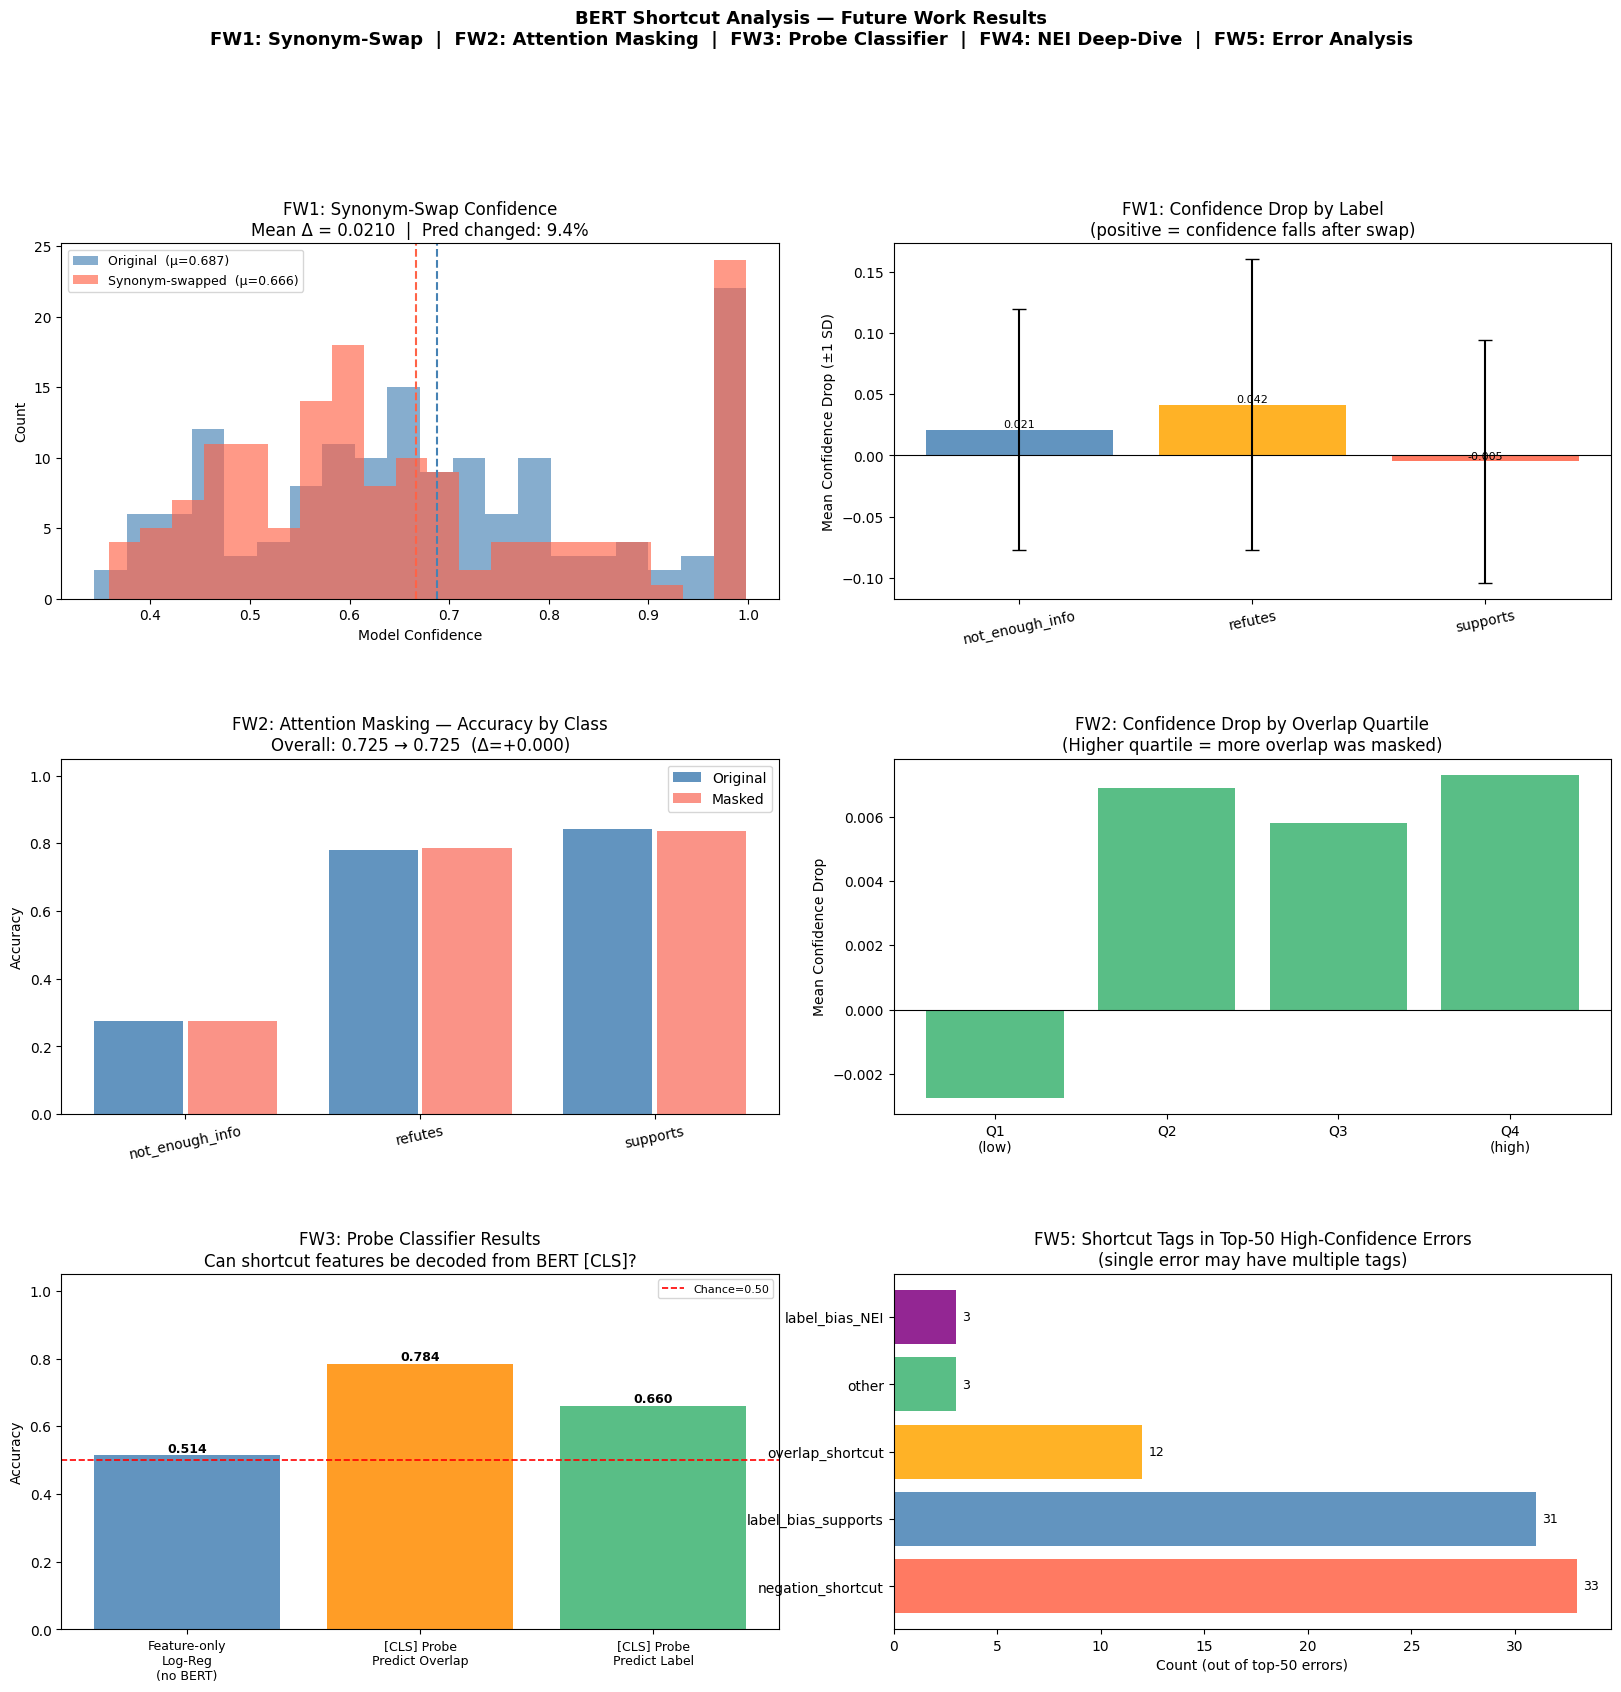

In [ ]:
COLORS = ["steelblue", "tomato", "orange"]

fig = plt.figure(figsize=(20, 18))
fig.suptitle(
    "BERT Shortcut Analysis — Future Work Results\n"
    "FW1: Synonym-Swap  |  FW2: Attention Masking  |  FW3: Probe Classifier  |  FW4: NEI Deep-Dive  |  FW5: Error Analysis",
    fontsize=13, fontweight="bold", y=1.01
)

gs = gridspec.GridSpec(3, 4, figure=fig, hspace=0.45, wspace=0.38)

# ── FW1: Synonym-swap confidence distribution ─────────────────────────────────
ax1 = fig.add_subplot(gs[0, :2])
if swap_df is not None and len(swap_df):
    ax1.hist(swap_df["orig_confidence"], bins=20, alpha=0.65, color="steelblue",
             label=f"Original  (μ={swap_df['orig_confidence'].mean():.3f})")
    ax1.hist(swap_df["swap_confidence"], bins=20, alpha=0.65, color="tomato",
             label=f"Synonym-swapped  (μ={swap_df['swap_confidence'].mean():.3f})")
    ax1.axvline(swap_df["orig_confidence"].mean(), color="steelblue", ls="--", lw=1.5)
    ax1.axvline(swap_df["swap_confidence"].mean(), color="tomato",    ls="--", lw=1.5)
    ax1.set_title(f"FW1: Synonym-Swap Confidence\nMean Δ = {swap_df['conf_drop'].mean():.4f}  |  "
                  f"Pred changed: {swap_df['pred_changed'].mean()*100:.1f}%")
    ax1.set_xlabel("Model Confidence")
    ax1.set_ylabel("Count")
    ax1.legend(fontsize=9)
else:
    ax1.text(0.5, 0.5, "No swap data", ha="center", va="center", transform=ax1.transAxes)
    ax1.set_title("FW1: Synonym-Swap (no data)")

# ── FW1: Confidence drop by label ────────────────────────────────────────────
ax2 = fig.add_subplot(gs[0, 2:])
if swap_df is not None and len(swap_df):
    grp = swap_df.groupby("label_name")["conf_drop"].agg(["mean", "std"])
    x   = np.arange(len(grp))
    bars = ax2.bar(x, grp["mean"], yerr=grp["std"], capsize=5,
                   color=["steelblue","orange","tomato"], alpha=0.85)
    ax2.axhline(0, color="k", lw=0.8)
    ax2.set_xticks(x)
    ax2.set_xticklabels(grp.index, rotation=12)
    ax2.set_title("FW1: Confidence Drop by Label\n(positive = confidence falls after swap)")
    ax2.set_ylabel("Mean Confidence Drop (±1 SD)")
    for b, v in zip(bars, grp["mean"]):
        ax2.text(b.get_x() + b.get_width()/2, v + 0.002, f"{v:.3f}",
                 ha="center", fontsize=8)

# ── FW2: Accuracy before vs. after masking ───────────────────────────────────
ax3 = fig.add_subplot(gs[1, :2])
if mask_df is not None and len(mask_df):
    agg = mask_df.groupby("label_name")[["orig_correct","mask_correct"]].mean()
    x   = np.arange(len(agg))
    ax3.bar(x - 0.2, agg["orig_correct"], 0.38, label="Original",  color="steelblue", alpha=0.85)
    ax3.bar(x + 0.2, agg["mask_correct"], 0.38, label="Masked",    color="salmon",    alpha=0.85)
    ax3.set_xticks(x)
    ax3.set_xticklabels(agg.index, rotation=12)
    ax3.set_ylim(0, 1.05)
    ax3.set_title(f"FW2: Attention Masking — Accuracy by Class\n"
                  f"Overall: {mask_df['orig_correct'].mean():.3f} → {mask_df['mask_correct'].mean():.3f}  "
                  f"(Δ={mask_df['mask_correct'].mean()-mask_df['orig_correct'].mean():+.3f})")
    ax3.set_ylabel("Accuracy")
    ax3.legend()

# ── FW2: Confidence drop by overlap quartile ─────────────────────────────────
ax4 = fig.add_subplot(gs[1, 2:])
if mask_df is not None and len(mask_df):
    mask_df["ov_q"] = pd.qcut(mask_df["overlap"], q=4,
                               labels=["Q1\n(low)","Q2","Q3","Q4\n(high)"])
    q_grp = mask_df.groupby("ov_q", observed=False)["conf_drop"].mean()
    ax4.bar(range(4), q_grp.values, color="mediumseagreen", alpha=0.85)
    ax4.set_xticks(range(4))
    ax4.set_xticklabels(q_grp.index)
    ax4.set_title("FW2: Confidence Drop by Overlap Quartile\n"
                  "(Higher quartile = more overlap was masked)")
    ax4.set_ylabel("Mean Confidence Drop")
    ax4.axhline(0, color="k", lw=0.8)

# ── FW3: Probe accuracy comparison ───────────────────────────────────────────
ax5 = fig.add_subplot(gs[2, :2])
probe_labels = ["Feature-only\nLog-Reg\n(no BERT)",
                "[CLS] Probe\nPredict Overlap",
                "[CLS] Probe\nPredict Label"]
probe_accs   = [
    probe_results["feature_only_accuracy"],
    probe_results["overlap_probe_accuracy"],
    probe_results["label_probe_accuracy"],
]
chance_line  = probe_results["overlap_probe_chance"]
bars = ax5.bar(range(3), probe_accs,
               color=["steelblue","darkorange","mediumseagreen"], alpha=0.85)
ax5.axhline(chance_line, color="red", ls="--", lw=1.2, label=f"Chance={chance_line:.2f}")
ax5.set_xticks(range(3))
ax5.set_xticklabels(probe_labels, fontsize=9)
ax5.set_ylim(0, 1.05)
ax5.set_title("FW3: Probe Classifier Results\n"
              "Can shortcut features be decoded from BERT [CLS]?")
ax5.set_ylabel("Accuracy")
ax5.legend(fontsize=8)
for b, v in zip(bars, probe_accs):
    ax5.text(b.get_x() + b.get_width()/2, v + 0.01, f"{v:.3f}",
             ha="center", fontsize=9, fontweight="bold")

# ── FW5: Shortcut tag distribution in top-50 errors ──────────────────────────
ax6 = fig.add_subplot(gs[2, 2:])
if error_df is not None and len(error_df):
    all_tags = []
    for t in error_df["shortcut_tags"]:
        all_tags.extend(t.split("|"))
    tag_cnt  = Counter(all_tags)
    tags, cnts = zip(*tag_cnt.most_common())
    ax6.barh(tags, cnts,
             color=["tomato","steelblue","orange","mediumseagreen","purple"][:len(tags)],
             alpha=0.85)
    ax6.set_xlabel("Count (out of top-50 errors)")
    ax6.set_title("FW5: Shortcut Tags in Top-50 High-Confidence Errors\n"
                  "(single error may have multiple tags)")
    for i, (_, v) in enumerate(tag_cnt.most_common()):
        ax6.text(v + 0.3, i, str(v), va="center", fontsize=9)

out_path = os.path.join(OUTPUT_DIR, "future_works_summary.png")
plt.savefig(out_path, dpi=150, bbox_inches="tight")
print(f"Figure saved → {out_path}")
plt.show()

## Save Combined JSON Summary

In [ ]:
summary = {
    "dataset": "PubHealth",
    "model":   MODEL_NAME,
    "val_n":   len(dev_df),
    "fw1_synonym_swap": {
        "n_samples": len(swap_df) if swap_df is not None and len(swap_df) else 0,
        "mean_conf_drop":   float(swap_df["conf_drop"].mean())   if swap_df is not None and len(swap_df) else None,
        "pct_pred_changed": float(swap_df["pred_changed"].mean()*100) if swap_df is not None and len(swap_df) else None,
    },
    "fw2_attention_masking": {
        "n_samples":        len(mask_df),
        "orig_accuracy":    float(mask_df["orig_correct"].mean()),
        "masked_accuracy":  float(mask_df["mask_correct"].mean()),
        "mean_conf_drop":   float(mask_df["conf_drop"].mean()),
        "pct_pred_changed": float(mask_df["pred_changed"].mean()*100),
    },
    "fw3_probe_classifier": probe_results,
    "fw4_nei_deep_dive": {
        "nei_count":        int((feat_df_full["label_name"]=="not_enough_info").sum()),
        "nei_accuracy":     float(feat_df_full[feat_df_full["label_name"]=="not_enough_info"]["correct"].mean()),
        "nei_mean_confidence": float(feat_df_full[feat_df_full["label_name"]=="not_enough_info"]["confidence"].mean()),
        "non_nei_accuracy": float(feat_df_full[feat_df_full["label_name"]!="not_enough_info"]["correct"].mean()),
    },
    "fw5_error_analysis": {
        "total_errors": int((feat_df_full["correct"]==0).sum()),
        "top50_tag_distribution": {
            t: c for t, c in Counter(
                [tag for tags in error_df["shortcut_tags"] for tag in tags.split("|")]
            ).most_common()
        }
    }
}

json_path = os.path.join(OUTPUT_DIR, "future_works_summary.json")
with open(json_path, "w") as f:
    json.dump(summary, f, indent=2)
print(f"Summary JSON → {json_path}")
print(json.dumps(summary, indent=2))

Summary JSON → ./future_works_outputs/future_works_summary.json
{
  "dataset": "PubHealth",
  "model": "bert-base-uncased",
  "val_n": 1223,
  "fw1_synonym_swap": {
    "n_samples": 149,
    "mean_conf_drop": 0.021001932805016537,
    "pct_pred_changed": 9.395973154362416
  },
  "fw2_attention_masking": {
    "n_samples": 400,
    "orig_accuracy": 0.725,
    "masked_accuracy": 0.725,
    "mean_conf_drop": 0.004313513711094856,
    "pct_pred_changed": 1.25
  },
  "fw3_probe_classifier": {
    "feature_only_accuracy": 0.5143090760425184,
    "feature_only_macro_f1": 0.4069178620215245,
    "overlap_probe_accuracy": 0.7843137254901961,
    "overlap_probe_chance": 0.5004088307440719,
    "label_probe_accuracy": 0.6601307189542484,
    "label_probe_macro_f1": 0.5725418633068519
  },
  "fw4_nei_deep_dive": {
    "nei_count": 0,
    "nei_accuracy": NaN,
    "nei_mean_confidence": NaN,
    "non_nei_accuracy": 0.7228127555192151
  },
  "fw5_error_analysis": {
    "total_errors": 339,
    "top50

---
## Results Summary Table

In [ ]:
print("=" * 70)
print("FUTURE WORK EXPERIMENTS — CONSOLIDATED RESULTS")
print("=" * 70)

if swap_df is not None and len(swap_df):
    drop = swap_df["conf_drop"].mean()
    verdict = "⚠ Shortcut signal" if drop > 0.02 else "✓ Robust"
    print(f"\nFW1 Synonym-Swap         : Conf drop = {drop:.4f}  →  {verdict}")

d_acc = mask_df['mask_correct'].mean() - mask_df['orig_correct'].mean()
verdict = "⚠ Shortcut signal" if d_acc < -0.03 else "✓ Robust"
print(f"FW2 Attention Masking    : Acc Δ = {d_acc:+.4f}  →  {verdict}")

ov_probe = probe_results["overlap_probe_accuracy"]
chance   = probe_results["overlap_probe_chance"]
verdict  = "⚠ Encoded in [CLS]" if ov_probe > chance + 0.05 else "✓ Not linearly encoded"
print(f"FW3 Probe (Overlap→CLS)  : Acc = {ov_probe:.4f}  (chance {chance:.4f})  →  {verdict}")

nei_acc  = feat_df_full[feat_df_full["label_name"]=="not_enough_info"]["correct"].mean()
nnei_acc = feat_df_full[feat_df_full["label_name"]!="not_enough_info"]["correct"].mean()
verdict  = "⚠ Class-prior shortcut" if nei_acc > nnei_acc else "✓ NEI is harder"
print(f"FW4 NEI Deep-Dive        : NEI acc={nei_acc:.4f}  Non-NEI acc={nnei_acc:.4f}  →  {verdict}")

tag_cnt = Counter([t for tags in error_df["shortcut_tags"] for t in tags.split("|")])
top_tag = tag_cnt.most_common(1)[0]
print(f"FW5 Error Analysis       : Dominant shortcut = '{top_tag[0]}' ({top_tag[1]}/50 errors)")
print("=" * 70)

FUTURE WORK EXPERIMENTS — CONSOLIDATED RESULTS

FW1 Synonym-Swap         : Conf drop = 0.0210  →  ⚠ Shortcut signal
FW2 Attention Masking    : Acc Δ = +0.0000  →  ✓ Robust
FW3 Probe (Overlap→CLS)  : Acc = 0.7843  (chance 0.5004)  →  ⚠ Encoded in [CLS]
FW4 NEI Deep-Dive        : NEI acc=nan  Non-NEI acc=0.7228  →  ✓ NEI is harder
FW5 Error Analysis       : Dominant shortcut = 'negation_shortcut' (33/50 errors)
